# Task 1B — Analytical Questions

Five (plus one) questions about the PJME series, each with a visualization and what
I read from it. Two of them lean directly on the engineered features: **Q3** on lagged
values and **Q4** on moving averages.


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

from src.preprocessing import load_series, make_hourly, build_features

sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "outputs" / "figures"

df = make_hourly(load_series("PJME"))
feat = build_features("PJME")          # same series + lag/rolling columns
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## Q1 — Is there a long-term trend in demand?

I fit a straight line to the daily average demand against time and check whether the
slope is meaningfully different from flat.


Trend: -82 MW per year   (p = 5.84e-11)
Mean demand: 32079 MW


C:\Users\samue\AppData\Local\Temp\ipykernel_11116\1750718986.py:11: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(daily.index, model.predict(sm.add_constant(t)), "r", lw=2, label="linear trend")


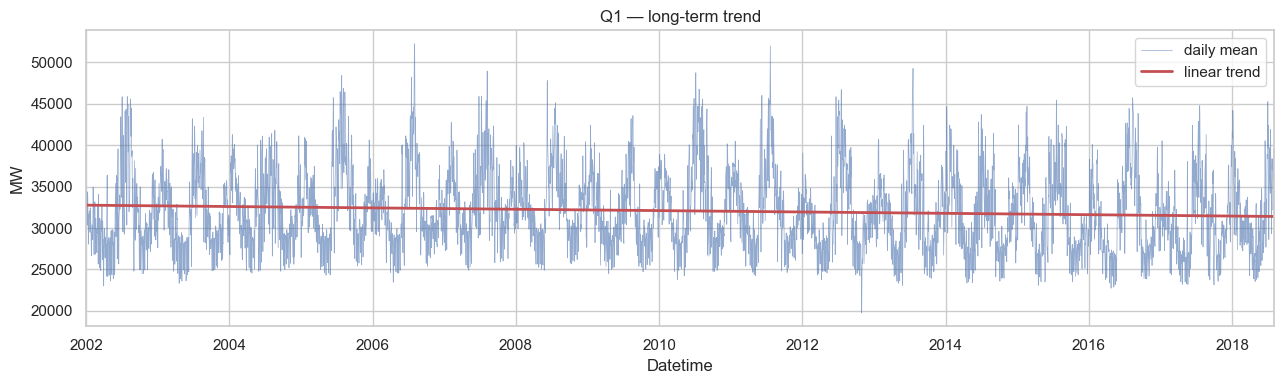

In [2]:
daily = df["PJME_MW"].resample("D").mean()
t = np.arange(len(daily))
model = sm.OLS(daily.values, sm.add_constant(t)).fit()
slope_per_year = model.params[1] * 365

print(f"Trend: {slope_per_year:+.0f} MW per year   (p = {model.pvalues[1]:.3g})")
print(f"Mean demand: {daily.mean():.0f} MW")

fig, ax = plt.subplots(figsize=(13, 4))
daily.plot(ax=ax, lw=0.5, alpha=0.6, label="daily mean")
ax.plot(daily.index, model.predict(sm.add_constant(t)), "r", lw=2, label="linear trend")
ax.set(title="Q1 — long-term trend", ylabel="MW"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "q1_trend.png", dpi=120); plt.show()

The fitted slope is **negative but tiny**: about **-82 MW per year** against a
~32,000 MW average, roughly 0.25% a year. The p-value is minuscule so the decline is
statistically real, but in practical terms the baseline is essentially flat — the
series is driven by season, not by long-run growth or decline. This is common for a
mature grid where efficiency gains roughly offset demand growth.


## Q2 — How different are weekdays from weekends?

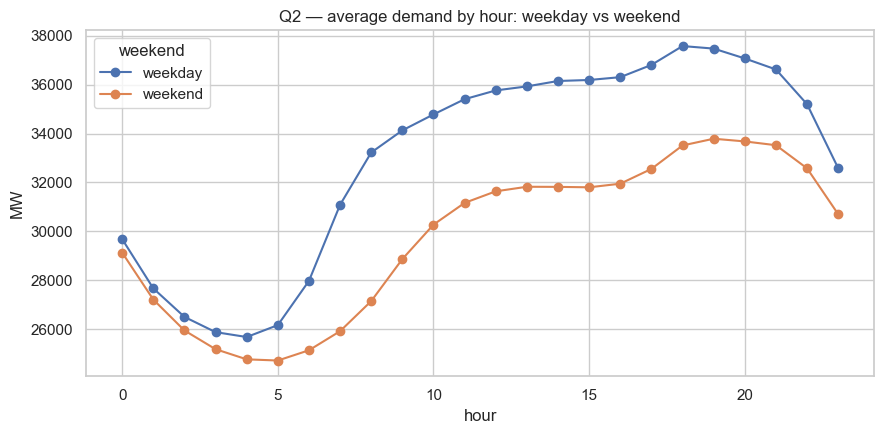

Weekdays run about 3212 MW higher on average across the day


In [3]:
prof = pd.DataFrame({"MW": df["PJME_MW"]})
prof["hour"] = prof.index.hour
prof["weekend"] = np.where(prof.index.dayofweek >= 5, "weekend", "weekday")

pivot = prof.groupby(["hour", "weekend"])["MW"].mean().unstack()
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot.plot(ax=ax, marker="o")
ax.set(title="Q2 — average demand by hour: weekday vs weekend", xlabel="hour", ylabel="MW")
fig.tight_layout(); fig.savefig(FIG / "q2_weekday_weekend.png", dpi=120); plt.show()

gap = (pivot["weekday"] - pivot["weekend"]).mean()
print(f"Weekdays run about {gap:.0f} MW higher on average across the day")

Both profiles share the same shape — overnight low, evening peak — but weekdays sit
noticeably higher, especially during working hours, because commercial and industrial
load is on. Weekends flatten the morning ramp. This is why `dayofweek` and `is_weekend`
are useful model features.


## Q3 — Lag effect: how strongly does demand depend on its own past?

This is the lagged-feature question. I look at the autocorrelation of the series and
at how well earlier readings line up with the current hour.


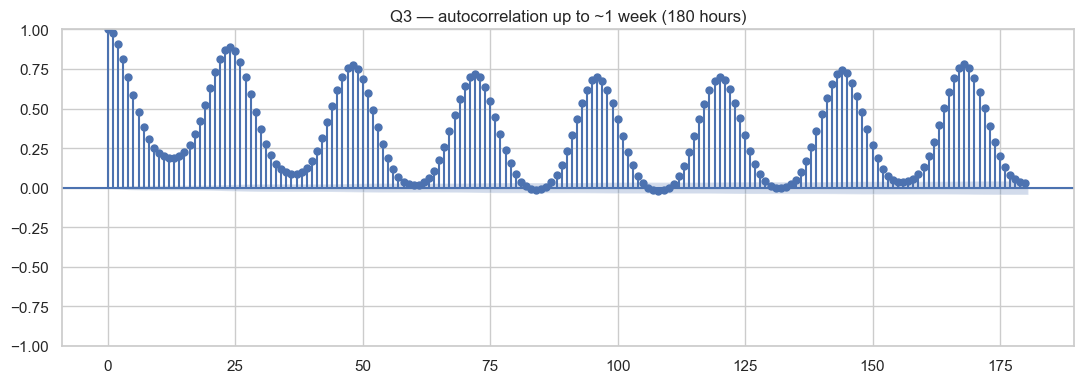

corr(PJME_MW, lag_1h) = 0.975
corr(PJME_MW, lag_24h) = 0.891
corr(PJME_MW, lag_168h) = 0.782


In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(df["PJME_MW"], lags=180, ax=ax)
ax.set(title="Q3 — autocorrelation up to ~1 week (180 hours)")
fig.tight_layout(); fig.savefig(FIG / "q3_acf.png", dpi=120); plt.show()

for col in ["lag_1h", "lag_24h", "lag_168h"]:
    r = feat["PJME_MW"].corr(feat[col])
    print(f"corr(PJME_MW, {col}) = {r:.3f}")

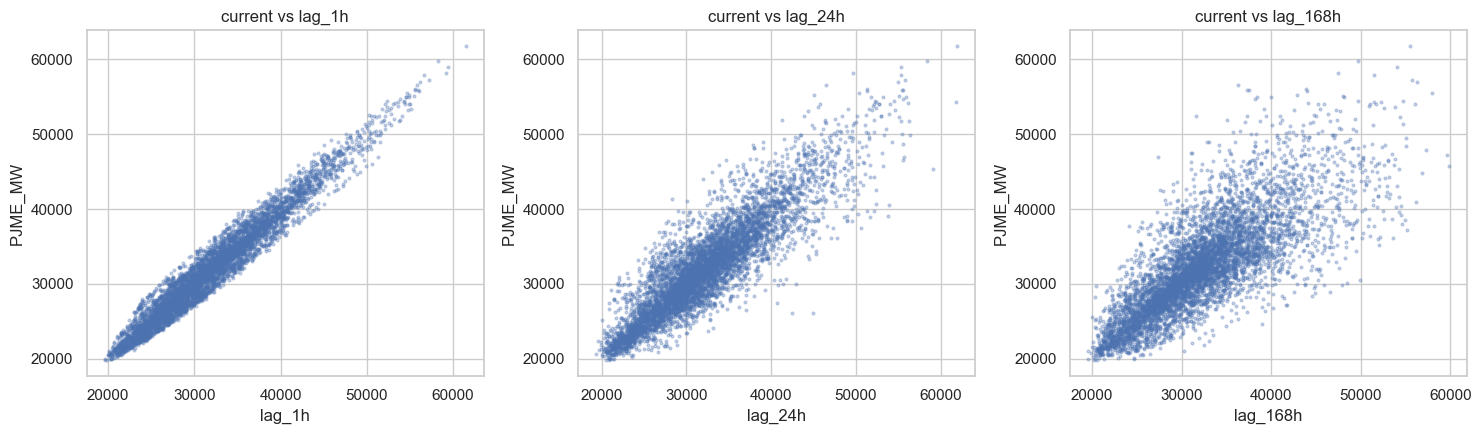

In [5]:
sample = feat.sample(6000, random_state=1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, col in zip(ax, ["lag_1h", "lag_24h", "lag_168h"]):
    a.scatter(sample[col], sample["PJME_MW"], s=4, alpha=0.3)
    a.set(title=f"current vs {col}", xlabel=col, ylabel="PJME_MW")
fig.tight_layout(); fig.savefig(FIG / "q3_lag_scatter.png", dpi=120); plt.show()

The ACF stays very high and shows clear spikes every **24 hours** and a strong one at
**168 hours** (one week) — demand this hour is closely tied to the same hour yesterday
and last week. The correlations confirm it: ~0.98 at 1 hour, ~0.89 at 24 hours and
~0.78 at 168 hours, and the scatter plots are tight diagonals. This is the single most
important finding for modeling: the recent past is a very strong predictor, which is
exactly why I engineer `lag_1h`, `lag_24h` and `lag_168h`.


## Q4 — What do moving averages reveal that the raw series hides?

The moving-average question. Hour-to-hour demand is noisy, so I smooth the daily series
with 7-day and 30-day rolling means to expose the underlying cycle.


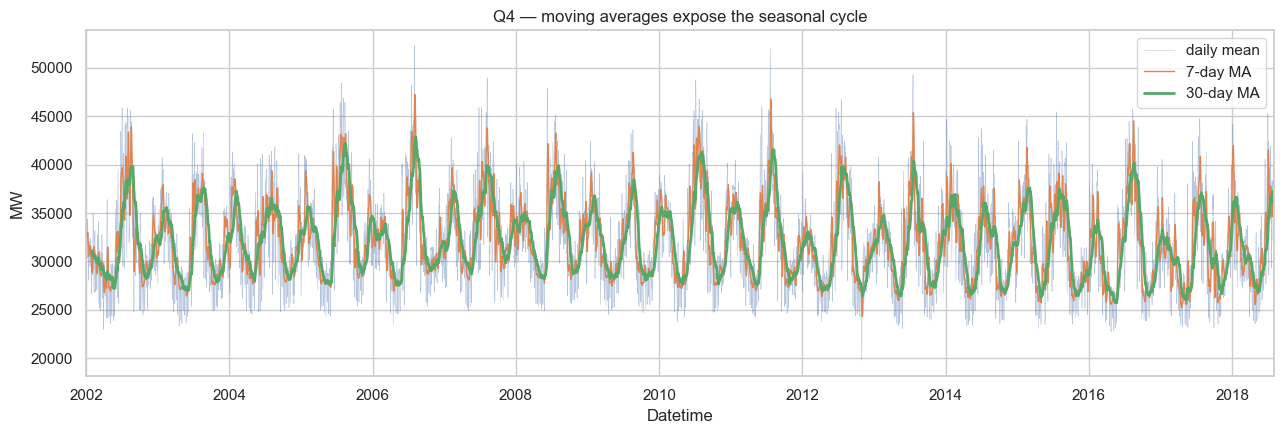

noise (std of daily): 4687
after 7-day smoothing: 3980


In [6]:
roll = pd.DataFrame({"daily": daily})
roll["ma_7d"] = daily.rolling(7).mean()
roll["ma_30d"] = daily.rolling(30).mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
roll["daily"].plot(ax=ax, lw=0.4, alpha=0.4, label="daily mean")
roll["ma_7d"].plot(ax=ax, lw=1, label="7-day MA")
roll["ma_30d"].plot(ax=ax, lw=2, label="30-day MA")
ax.set(title="Q4 — moving averages expose the seasonal cycle", ylabel="MW"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "q4_moving_average.png", dpi=120); plt.show()

print("noise (std of daily):", round(roll['daily'].std()))
print("after 7-day smoothing:", round(roll['ma_7d'].std()))

The 7-day average trims the day-to-day jitter (the std of the daily series drops from
~4,700 to ~4,000 MW) and the 30-day average traces a clean seasonal wave with summer
and winter humps each year. Isolating that slow-moving level is the point: a rolling
mean hands the model a stable "recent baseline" to anchor on, separate from the sharp
hourly swings. That's the reasoning behind `roll_mean_24h` and `roll_mean_168h`.


## Q5 — Do external variables track the target? (PJME vs neighbouring PJMW)

PJME on its own is univariate, so I bring in a second measured series — the neighbouring
**PJM West** region — and check whether it moves with PJME over time.


Overall PJME-PJMW correlation: 0.876


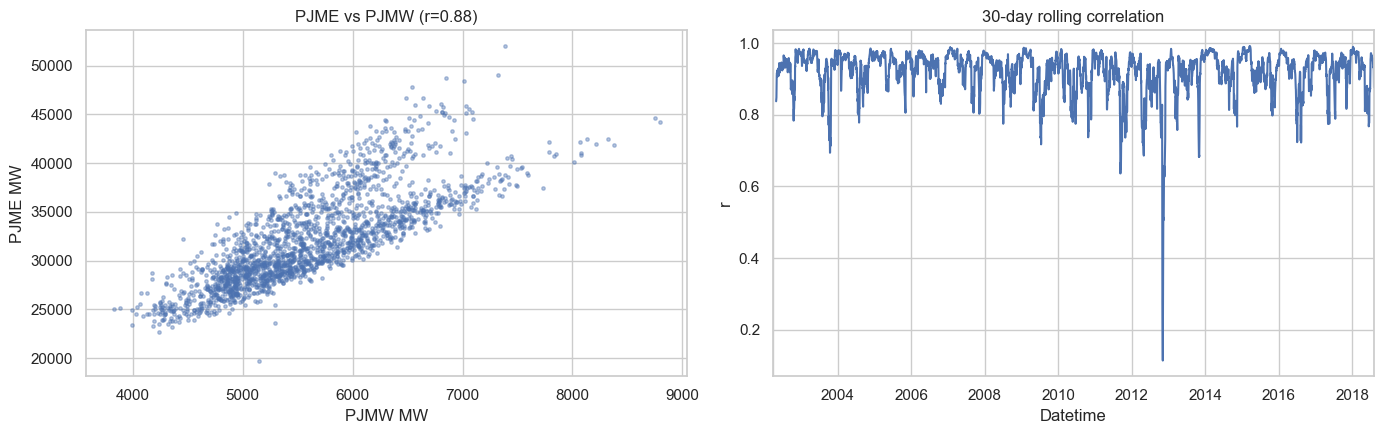

In [7]:
pjmw = make_hourly(load_series("PJMW")).rename(columns={"PJMW_MW": "PJMW_MW"})
both = df.join(pjmw, how="inner").dropna()

overall = both["PJME_MW"].corr(both["PJMW_MW"])
daily_both = both.resample("D").mean()
roll_corr = daily_both["PJME_MW"].rolling(30).corr(daily_both["PJMW_MW"])
print(f"Overall PJME-PJMW correlation: {overall:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
s = daily_both.sample(2000, random_state=1)
ax[0].scatter(s["PJMW_MW"], s["PJME_MW"], s=6, alpha=0.4)
ax[0].set(title=f"PJME vs PJMW (r={overall:.2f})", xlabel="PJMW MW", ylabel="PJME MW")
roll_corr.plot(ax=ax[1])
ax[1].set(title="30-day rolling correlation", ylabel="r")
fig.tight_layout(); fig.savefig(FIG / "q5_external_corr.png", dpi=120); plt.show()

PJME and PJMW are strongly correlated (r ≈ 0.88) — no surprise, they sit on the same
grid and share the same weather and calendar drivers. The rolling correlation stays
high year-round but tightens in summer and winter, when both regions are pushed by the
same heating/cooling demand. So a neighbouring region carries real predictive signal
and would be a sensible exogenous feature if I extended the model beyond PJME's own history.


## Q6 — When exactly do the peaks land? (hour × month)

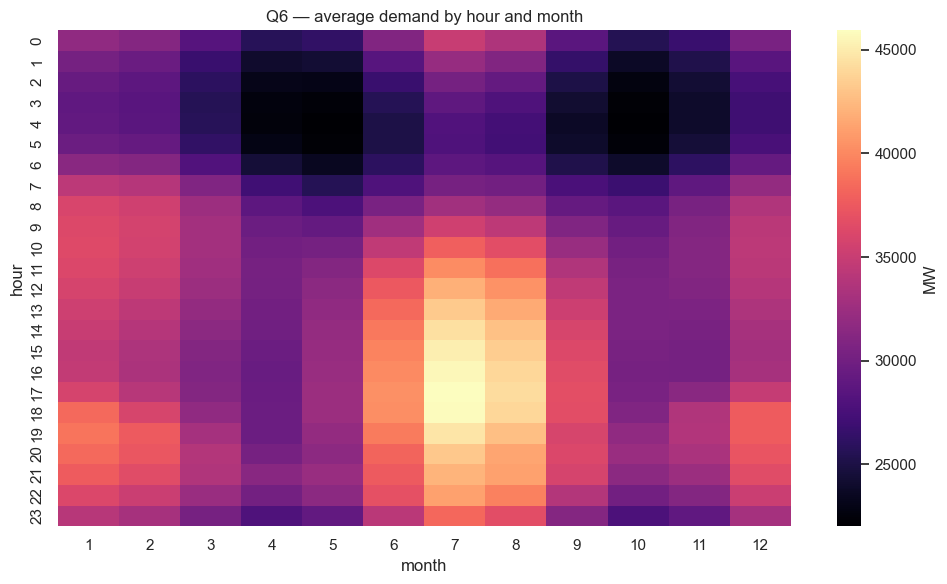

In [8]:
heat = df.copy()
heat["hour"] = heat.index.hour
heat["month"] = heat.index.month
grid = heat.groupby(["hour", "month"])["PJME_MW"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(grid, cmap="magma", ax=ax, cbar_kws={"label": "MW"})
ax.set(title="Q6 — average demand by hour and month", xlabel="month", ylabel="hour")
fig.tight_layout(); fig.savefig(FIG / "q6_heatmap.png", dpi=120); plt.show()

The hottest cells are **summer afternoons/evenings (Jul-Aug, hours 14-20)** — air-
conditioning driving the system peak — with a second, milder band in **January evenings**
from heating. Nights are low all year. The peak is therefore both seasonal and time-of-day
specific, which reinforces using hour, month and lag features together rather than any
one of them alone.


## Summary of findings

1. **No real trend** — the series is flat (slightly down) and driven by season.
2. **Weekdays > weekends**, sharing the same daily shape.
3. **Very strong lag structure** at 1h/24h/168h — the biggest lever for forecasting.
4. **Moving averages** expose a clean seasonal cycle under the hourly noise.
5. A **neighbouring region (PJMW) correlates ~0.9**, so external load carries signal.
6. Peaks are **summer evenings**, with a smaller winter-evening peak.
